In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv('../data/loan_defaulter.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Understanding the data

In [23]:
print(f'Data has {df.shape[0]} rows and {df.shape[1]} columns')

Data has 255347 rows and 18 columns


In [24]:
print("Columns: \n", df.columns)

Columns: 
 Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [26]:
# Checking null values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [27]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


* Age: The dataset covers a broad working-age demographic from 18 to 69 years old, with a mean age of 43.
* Income: Annual income is well-distributed, ranging from $15,000 to $150,000, with an average of $82,499.
* MonthsEmployed: On average, borrowers have been employed for 5 years (59.54 months)
* LoanAmount: The average loan amount is $127,578, with a maximum reach of $249,999.
* InterestRate: There is a massive spread in interest rates, from a low of 2% to a high of 25%, averaging at 13.5%.
* LoanTerm: Loans are relatively short to medium-term, ranging from 12 to 60 months (average of 36 months).
* CreditScore: The mean credit score is 574.
* DTIRatio: The average Debt-to-Income (DTI) ratio is 0.50.
* Default: The mean for the "Default" column is 0.116, indicating an overall default rate of 11.6% for this dataset.

In [28]:
df.dtypes

LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

In [29]:
# Dropped redundant columns
df.drop(columns=['LoanID'], inplace=True)

In [30]:
df.dtypes

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

# Exploratory Data Analysis

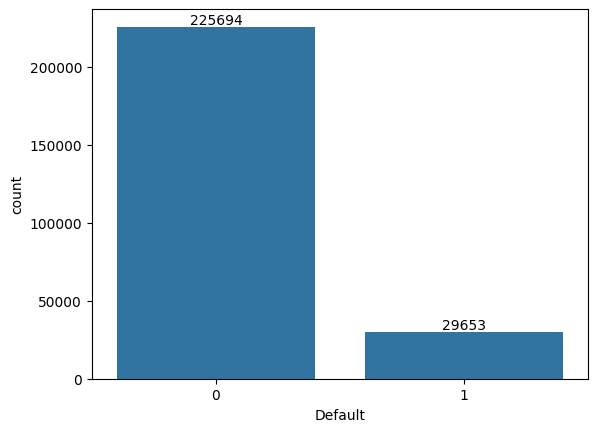

In [31]:
ax = sns.countplot(x='Default', data=df)
ax.bar_label(ax.containers[0])
plt.savefig("../images/default_bar_distribution.png", dpi=300, bbox_inches='tight')

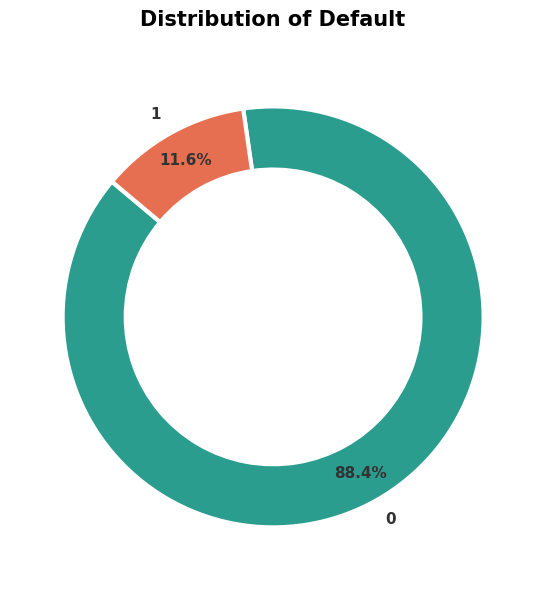

In [32]:
counts = df["Default"].value_counts()
plt.figure(figsize=(6, 6))
colors = ["#2A9D8F", "#E76F51"]
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140, colors=colors, pctdistance=0.85, textprops={"fontsize": 11, "weight": "bold", "color": "#333333"}, wedgeprops={"width": 0.3, "edgecolor": "white", "linewidth": 3},)
plt.title("Distribution of Default", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../images/default_pie_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
df.dtypes

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

In [34]:
# Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=['number']).columns.to_list()
categorical_columns = df.select_dtypes(include=['string']).columns.to_list()

print(f'We have {len(numerical_columns)} numerical columns: {numerical_columns}')
print(f'We have {len(categorical_columns)} categorical columns: {categorical_columns}')

We have 10 numerical columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
We have 7 categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


# Univariate Analysis of categorical variables

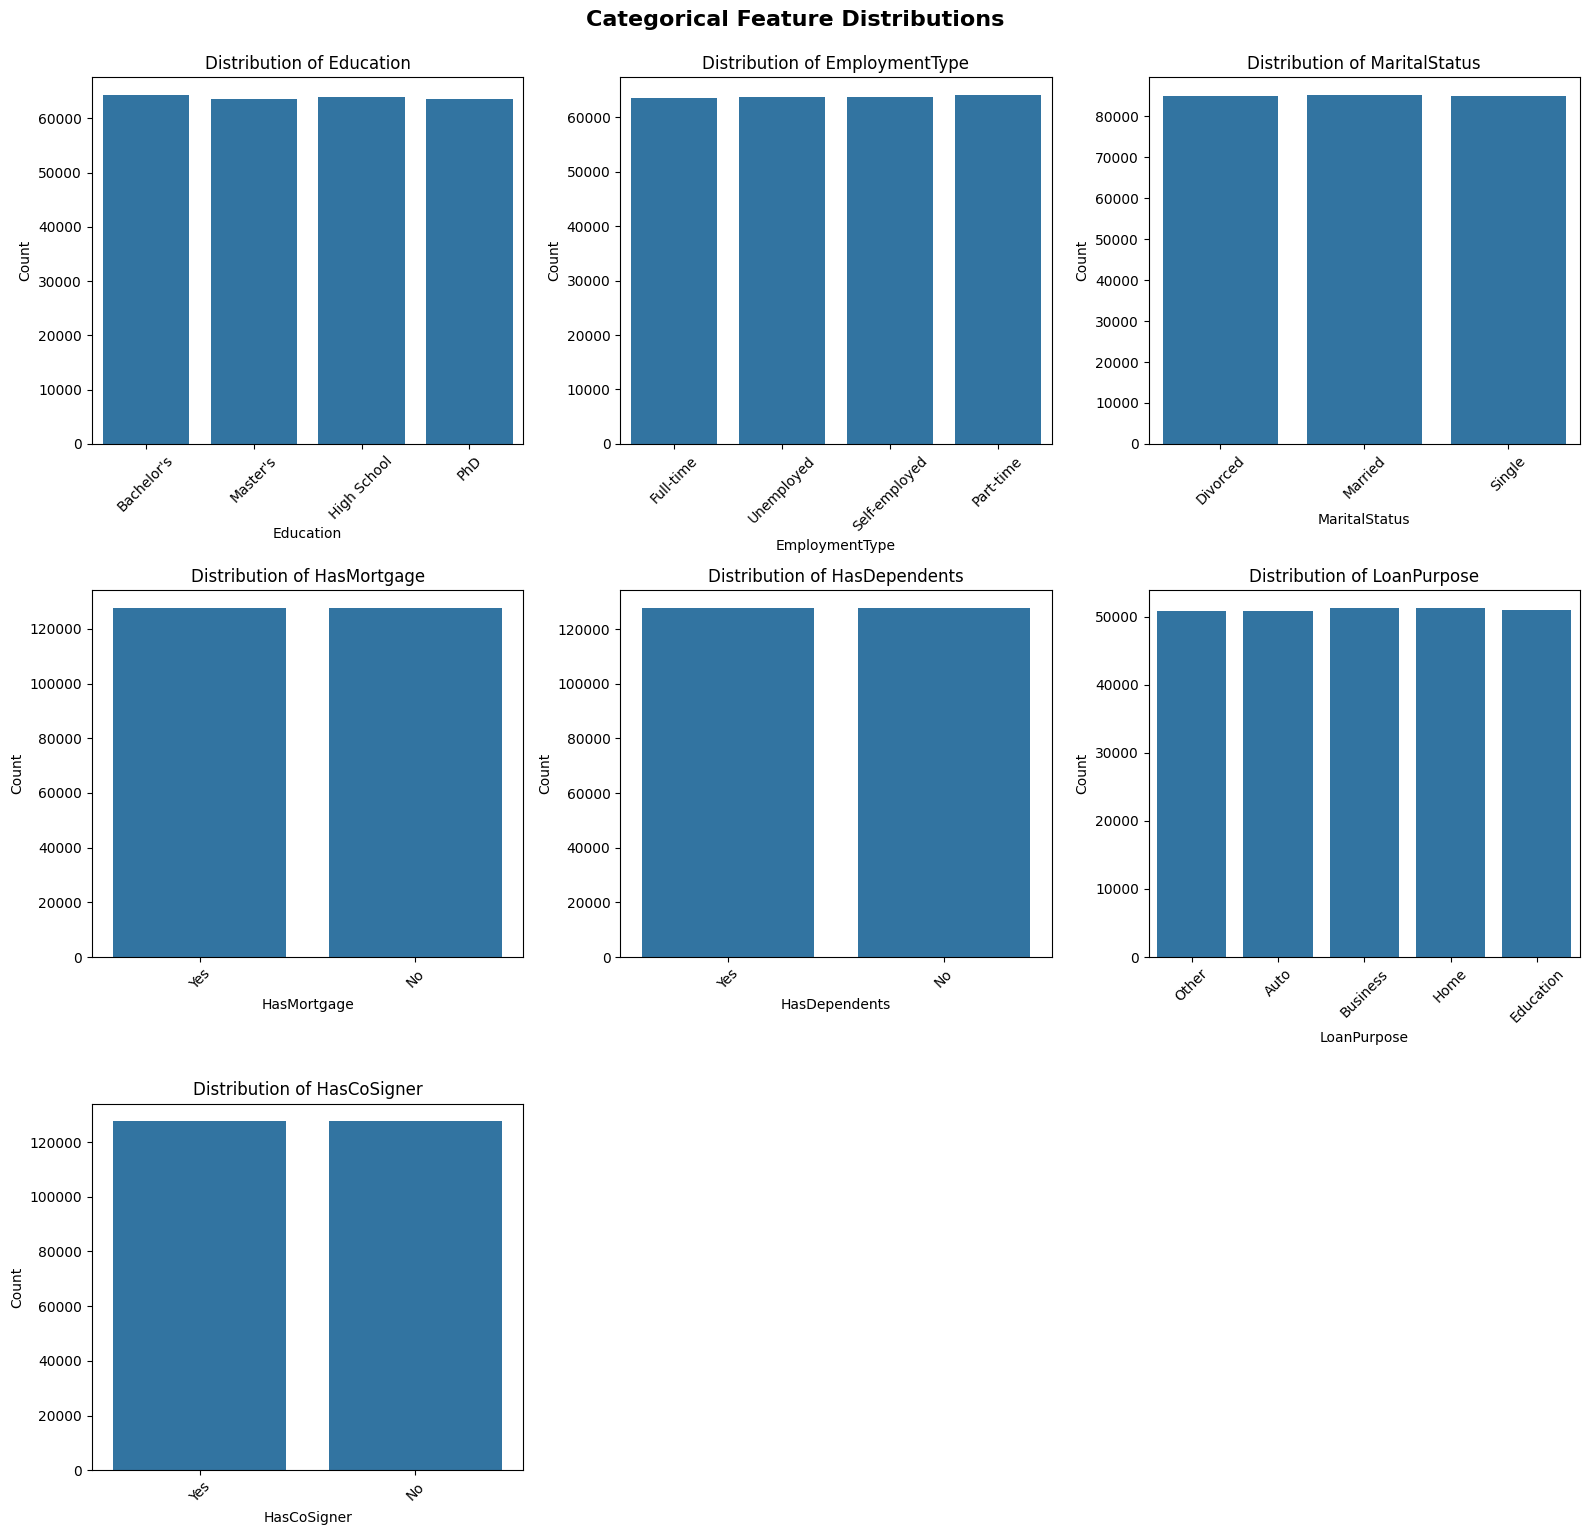

In [35]:
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig("../images/categorical_univariate_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Univariate Analysis of numerical variables

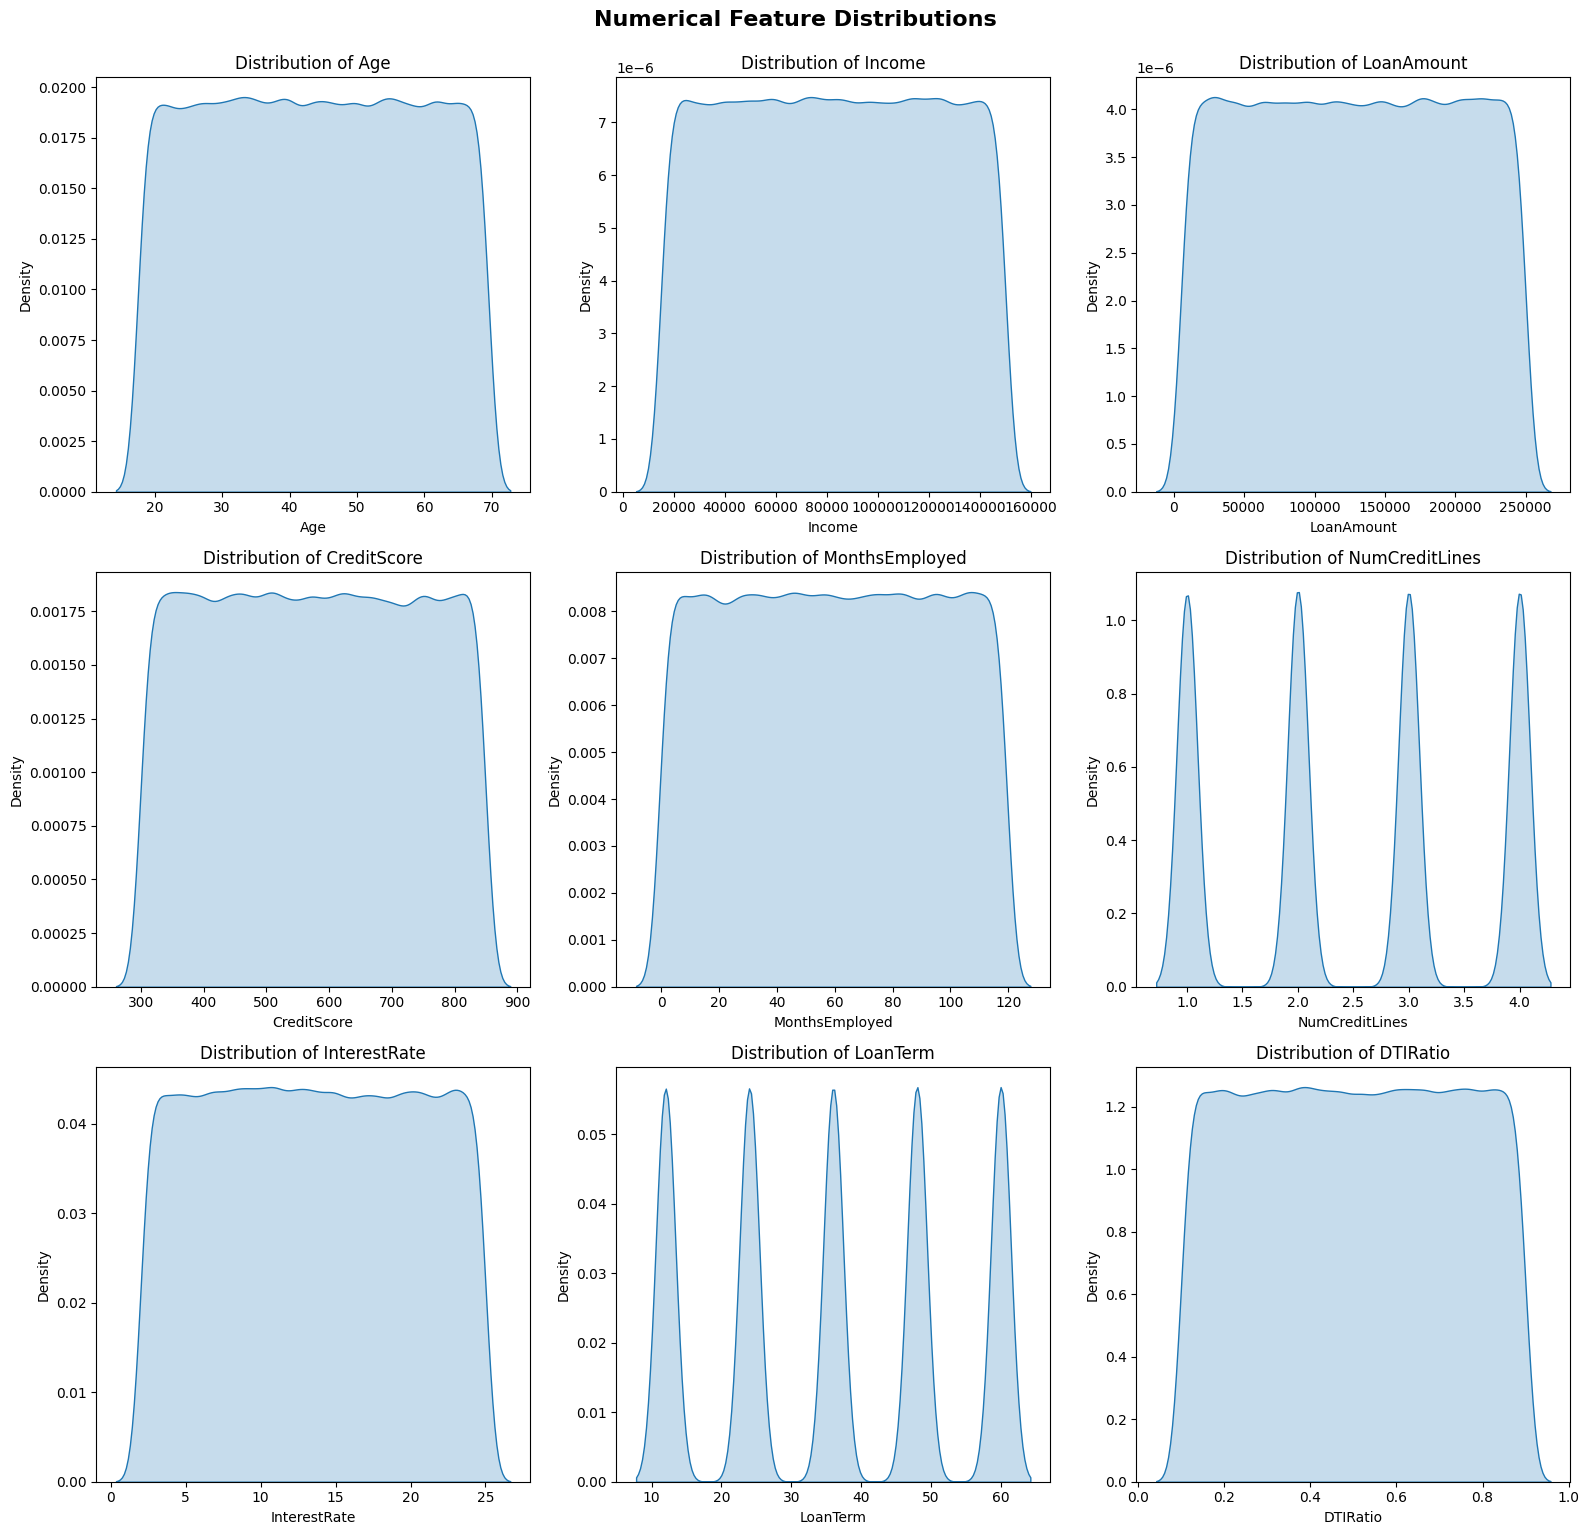

In [36]:
# Distribution Plots 
numerical_features = [column for column in numerical_columns if column != "Default"]

plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feature, fill=True, common_norm=False)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.savefig("../images/numerical_univariate_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Bivariate Analysis of categorical variables

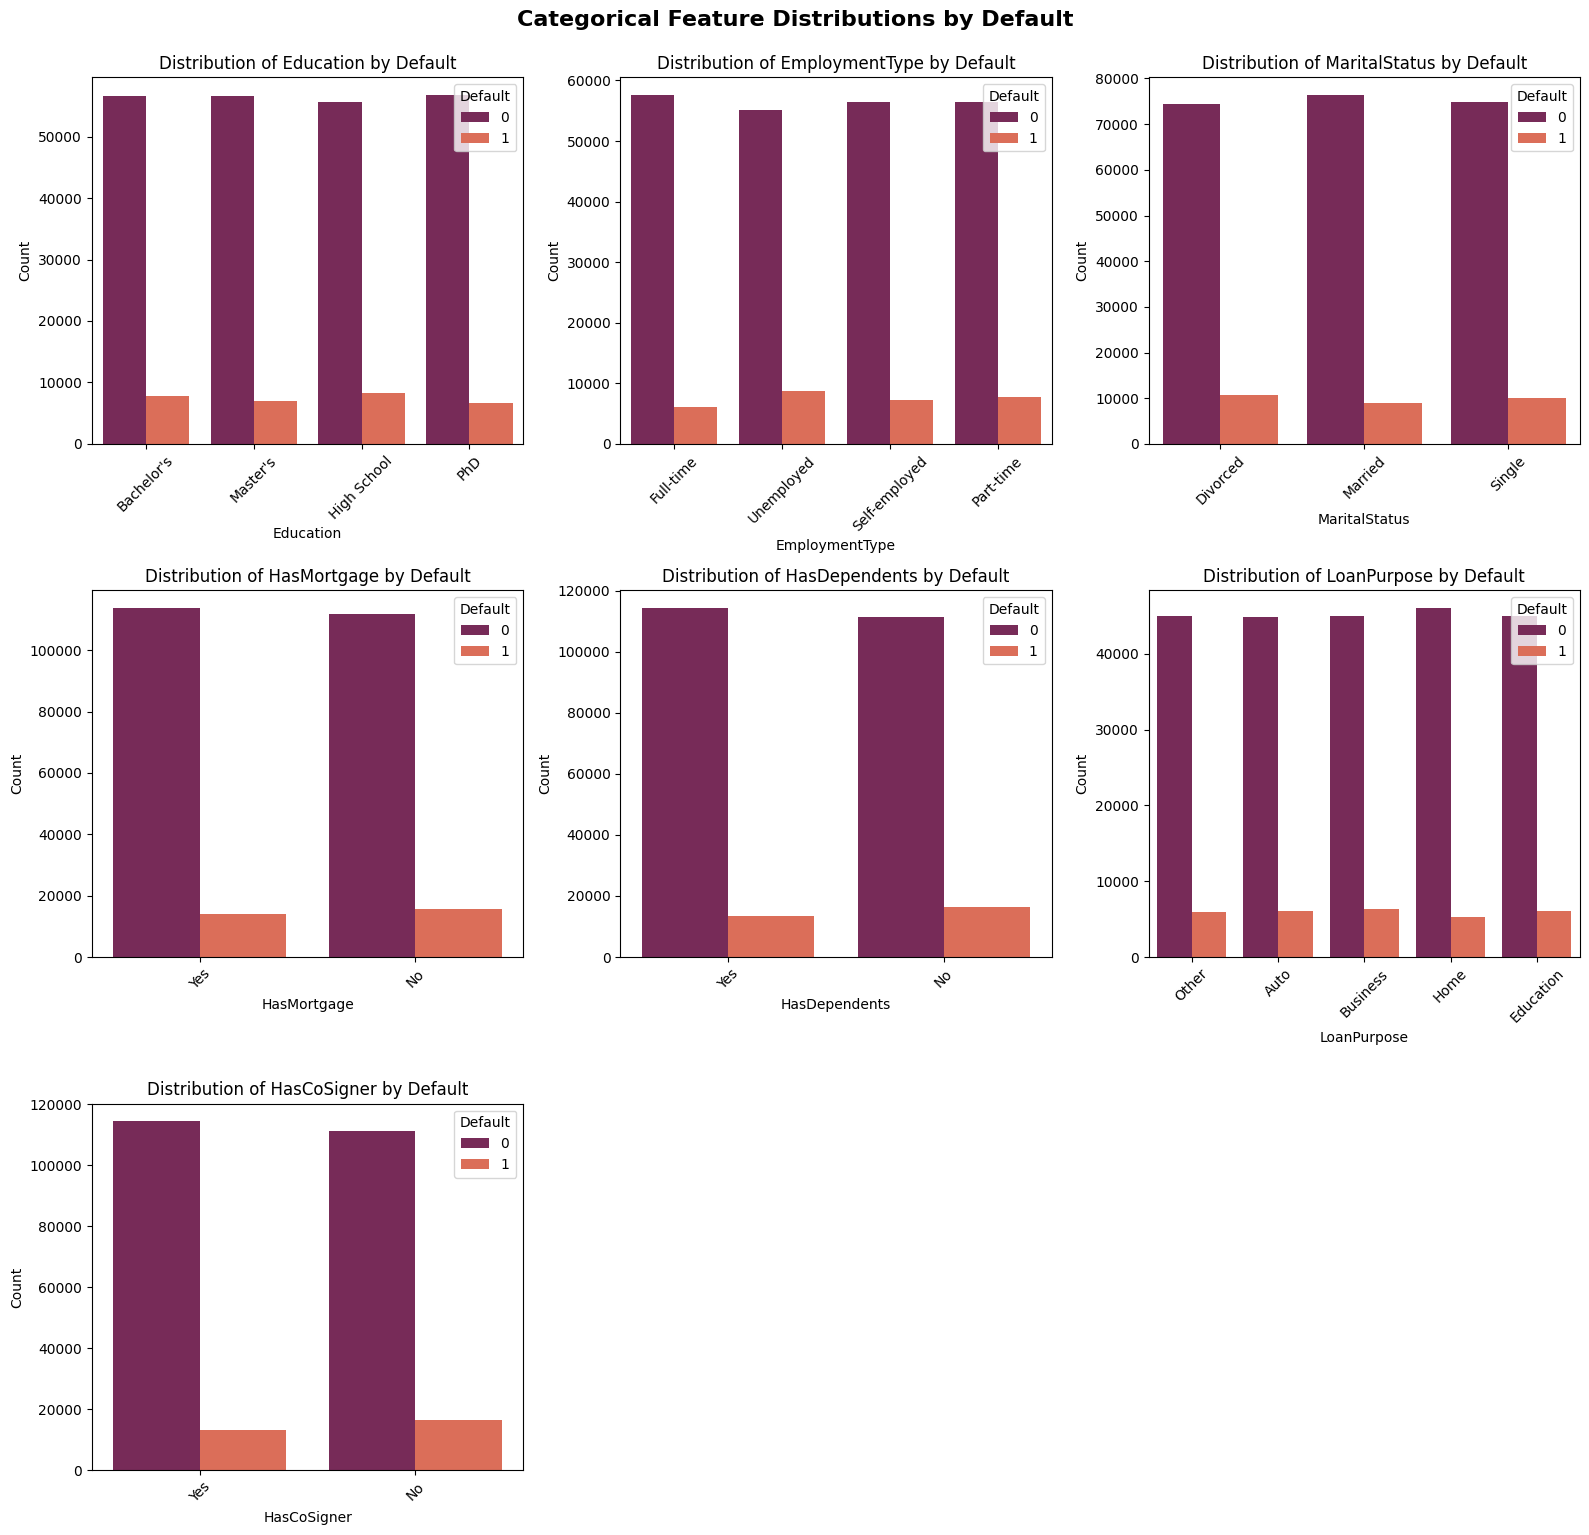

In [37]:
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature, hue='Default', palette='rocket')
    plt.title(f'Distribution of {feature} by Default')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions by Default", fontsize=16, y=1.02, fontweight='bold')
plt.savefig("../images/categorical_bivariate_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Bivariate Analysis of numerical variables

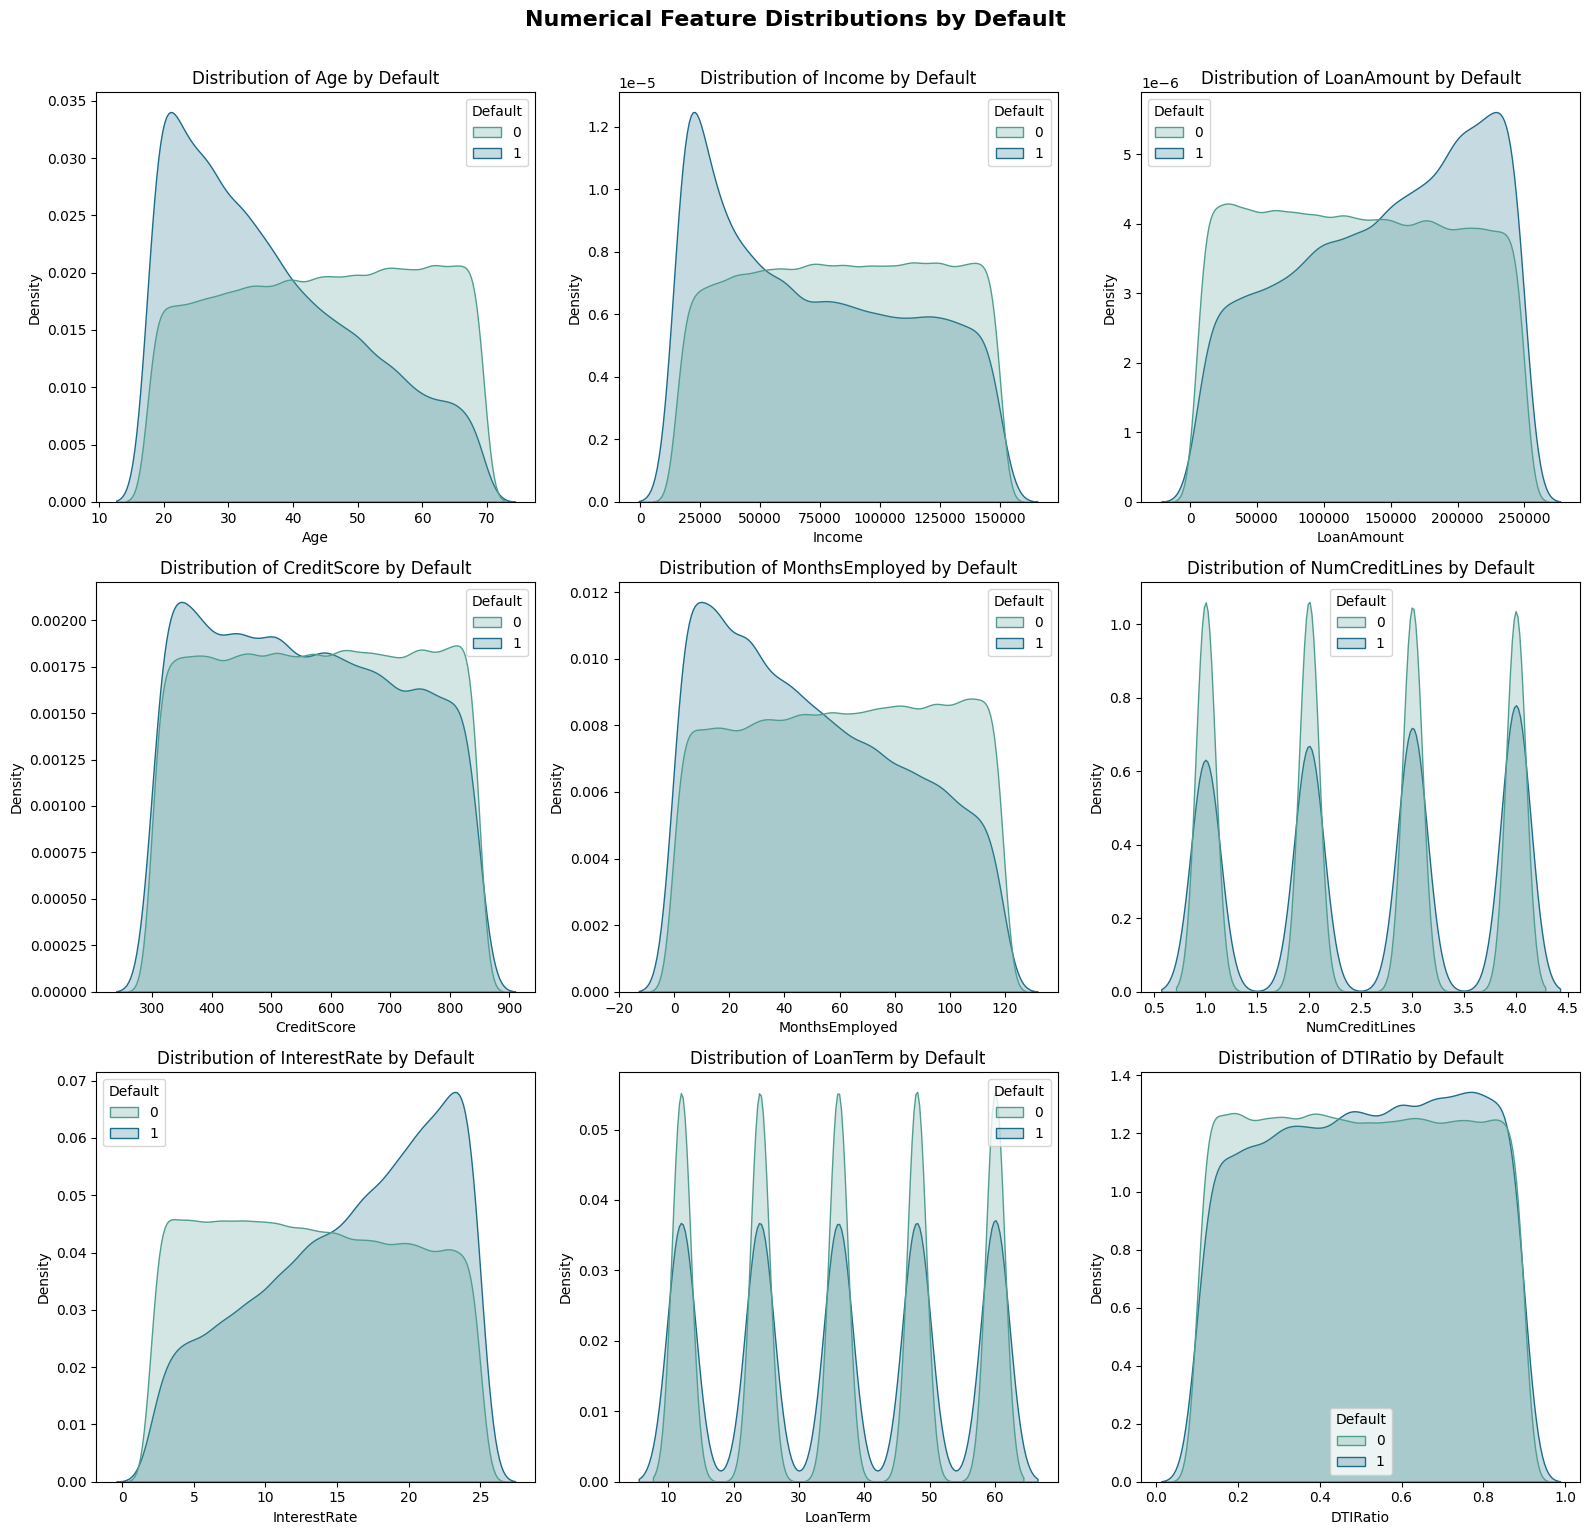

In [38]:
# Distribution Plots 
plt.figure(figsize=(16, 15))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feature, hue='Default', fill=True, common_norm=False, palette='crest')
    plt.title(f'Distribution of {feature} by Default')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions by Default", fontsize=16, y=1.02, fontweight='bold')
plt.savefig("../images/numerical_bivariate_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Feature Engineering

In [39]:
# To check someone earning 5k and asking for 50k loan = risky
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']

In [40]:
# High credit lines + low income = risky
df['Income_per_CreditLine'] = df['Income'] / (df['NumCreditLines'] + 1)

In [41]:
# Stable Employment = Stable Candidate
df['Employment_Stability'] = df['MonthsEmployed'] / (df['Age'] + 1)

In [42]:
# Higher Interest = High Pressure = Risky
df['Interest_Burden'] = df['LoanAmount'] * df['InterestRate']

In [43]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan_to_Income,Income_per_CreditLine,Employment_Stability,Interest_Burden
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,...,Divorced,Yes,Yes,Other,Yes,0,0.588262,17198.80,1.403509,770440.01
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,...,Married,No,No,Other,Yes,0,2.467481,25216.00,0.214286,598556.40
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,...,Divorced,Yes,Yes,Auto,No,1,1.534154,21052.00,0.553191,2734909.96
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,...,Married,No,No,Business,No,0,1.412638,7928.25,0.000000,316728.93
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,...,Divorced,No,Yes,Auto,No,0,0.447179,4087.40,0.131148,59494.89


In [44]:
df.shape

(255347, 21)

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Age                    255347 non-null  int64  
 1   Income                 255347 non-null  int64  
 2   LoanAmount             255347 non-null  int64  
 3   CreditScore            255347 non-null  int64  
 4   MonthsEmployed         255347 non-null  int64  
 5   NumCreditLines         255347 non-null  int64  
 6   InterestRate           255347 non-null  float64
 7   LoanTerm               255347 non-null  int64  
 8   DTIRatio               255347 non-null  float64
 9   Education              255347 non-null  str    
 10  EmploymentType         255347 non-null  str    
 11  MaritalStatus          255347 non-null  str    
 12  HasMortgage            255347 non-null  str    
 13  HasDependents          255347 non-null  str    
 14  LoanPurpose            255347 non-null  str    

In [46]:
# Feature Encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Loan_to_Income                255347 non-null  float64
 11  Income_per_CreditLine         255347 non-null  float64
 12  Employment_Stability          255347 non-null  float64


# Splitting features into X and y

In [48]:
X = df.drop('Default', axis=1)
y = df['Default']

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [51]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

    results_df = results_df.sort_values(by="Recall", ascending=False)
    print("\n\nModel Comparison:")
    print(results_df)


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.78     45170
           1       0.21      0.68      0.32      5900

    accuracy                           0.66     51070
   macro avg       0.57      0.67      0.55     51070
weighted avg       0.86      0.66      0.72     51070


Confusion Matrix:
[[29817 15353]
 [ 1902  3998]]


Model Comparison:
                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression   0.66213   0.855304  0.66213  0.722567

Model: KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45170
           1       0.28      0.06      0.10      5900

    accuracy                           0.87     51070
   macro avg       0.58      0.52      0.52     51070
weighted avg       0.82      0.87      0.84     51070


Confusion Matrix:
[[44240   930]
 [ 5537   363]]


Model Comp

`Recall is the most critical metric because failing to identify a defaulter (False Negative) can lead to direct financial losses for the bank. However, F1-score can also be used to balance recall with precision and evaluate performance on imbalanced datasets.`

### Logistic Regression catches 3,998 defaulters misses only 1,902 defaulters with Recall = 68%

In [52]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10], # Regularization (0.01-specify stronger regularization, 10-tell the model to trust the training data)
    'penalty': ['l2'] # (L2 - for ridge)
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), 
                    param_grid=params, 
                    scoring='recall',
                    cv=3)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(best_model)

LogisticRegression(C=10, max_iter=1000, penalty='l2')


In [53]:
logistic_model = LogisticRegression(class_weight='balanced', C=10, max_iter=1000, penalty='l2')
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.6693362052085373
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45170
           1       0.21      0.69      0.33      5900

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.55     51070
weighted avg       0.86      0.67      0.73     51070

[[30110 15060]
 [ 1827  4073]]


Logistic Regression with balanced class weights and hyperparameter tuning achieved a recall of 69% on the default class, correctly identifying 4,073 of 5,900 defaulters. Although ensemble methods achieved higher overall accuracy (~89%), they detected only 6–17% of defaulters. Since missing a defaulter leads to direct financial loss, recall was prioritized over accuracy, making the tuned Logistic Regression model the preferred solution.

In [54]:
# Save model
with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save feature names
with open("../model/feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!


In [56]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

                         Feature  Importance
0                            Age    0.293229
9                 Loan_to_Income    0.263236
6                   InterestRate    0.141839
4                 MonthsEmployed    0.099802
12               Interest_Burden    0.079877
10         Income_per_CreditLine    0.028470
27               HasCoSigner_Yes    0.014777
3                    CreditScore    0.013235
18     EmploymentType_Unemployed    0.012466
22             HasDependents_Yes    0.011597
1                         Income    0.007809
19         MaritalStatus_Married    0.005719
25              LoanPurpose_Home    0.004515
17  EmploymentType_Self-employed    0.003899
8                       DTIRatio    0.003359
21               HasMortgage_Yes    0.003310
13         Education_High School    0.003070
16      EmploymentType_Part-time    0.002380
5                 NumCreditLines    0.002282
15                 Education_PhD    0.001940


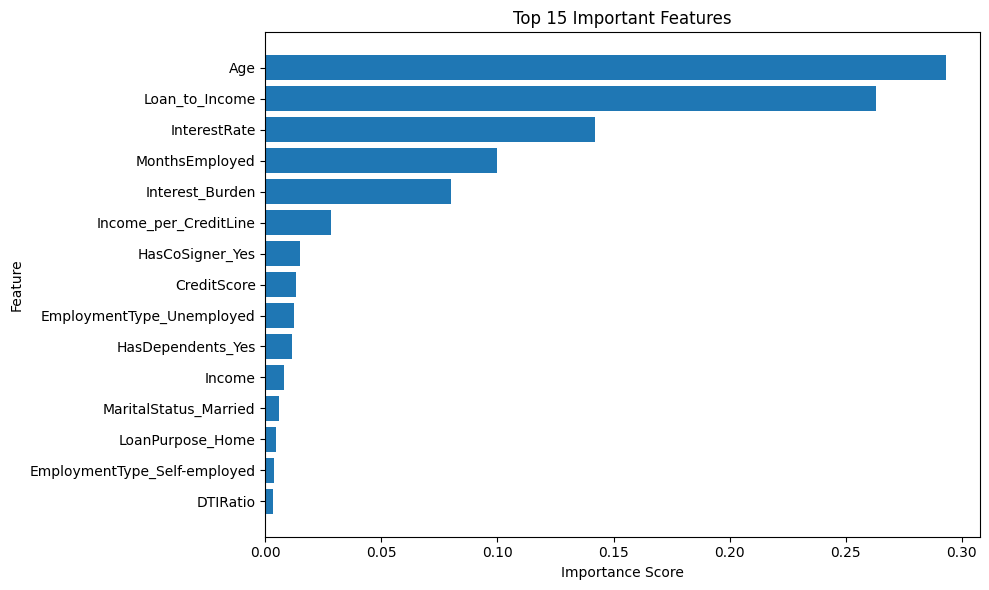

In [63]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches='tight')   